In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

In [2]:
with open('history_cce.pkl', 'rb') as f:
    cce_history = pickle.load(f)

with open('history_weighted.pkl', 'rb') as f:
    weighted_history = pickle.load(f)

with open('history_focal.pkl', 'rb') as f:
    focal_history = pickle.load(f)

In [3]:
try:
    with open('cce_metrics.pkl', 'rb') as f:
        cce_metrics = pickle.load(f)
    with open('weighted_metrics.pkl', 'rb') as f:
        weighted_metrics = pickle.load(f)
    with open('focal_metrics.pkl', 'rb') as f:
        focal_metrics = pickle.load(f)
    class_names = cce_metrics['class_names']
except FileNotFoundError:
    print("Metrics files not found. Please run the experiment notebooks first.")

Metrics files not found. Please run the experiment notebooks first.


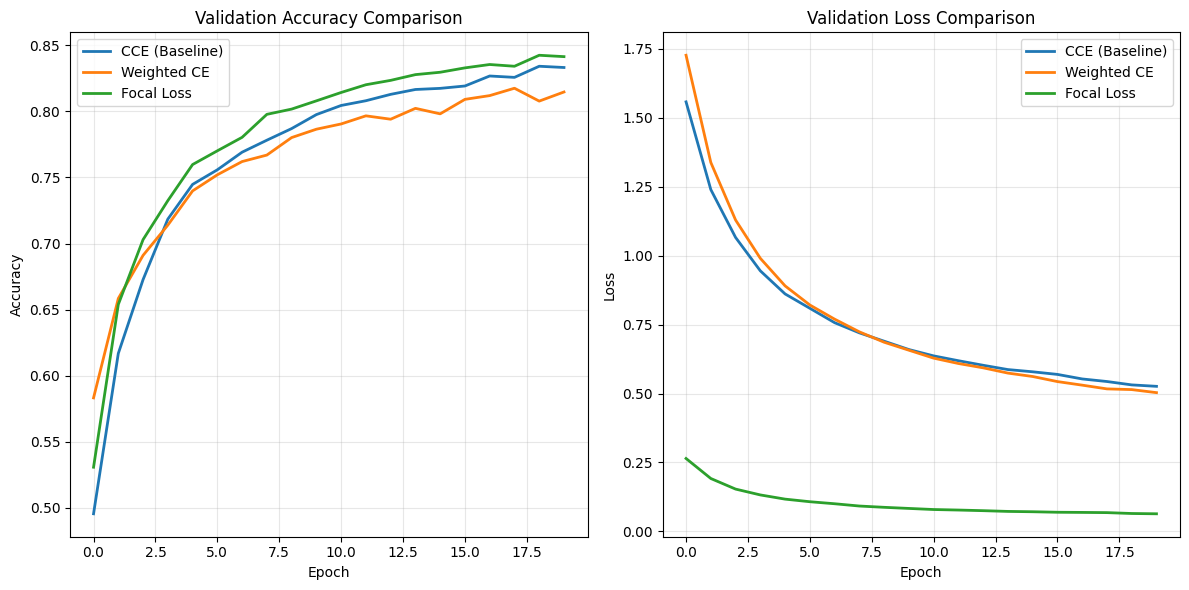

In [4]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(cce_history['val_accuracy'], label='CCE (Baseline)', linewidth=2)
plt.plot(weighted_history['val_accuracy'], label='Weighted CE', linewidth=2)
plt.plot(focal_history['val_accuracy'], label='Focal Loss', linewidth=2)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(cce_history['val_loss'], label='CCE (Baseline)', linewidth=2)
plt.plot(weighted_history['val_loss'], label='Weighted CE', linewidth=2)
plt.plot(focal_history['val_loss'], label='Focal Loss', linewidth=2)
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

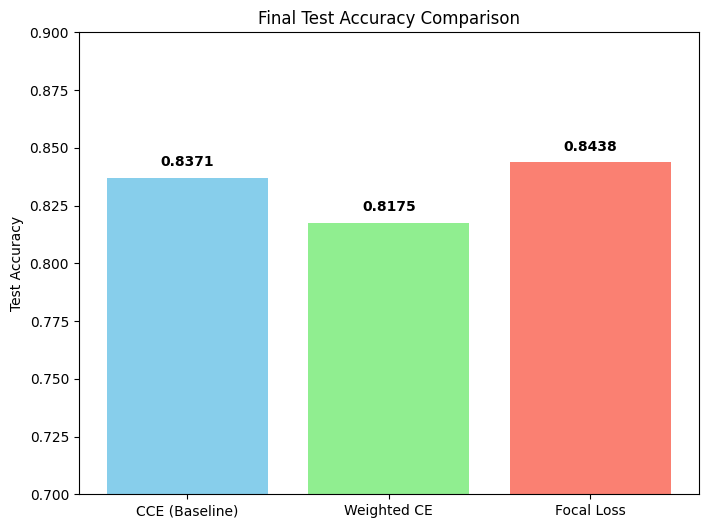

In [5]:
test_accuracies = {
    'CCE (Baseline)': 0.8371,
    'Weighted CE': 0.8175,
    'Focal Loss': 0.8438
}

plt.figure(figsize=(8, 6))
bars = plt.bar(test_accuracies.keys(), test_accuracies.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0.7, 0.9)
plt.ylabel('Test Accuracy')
plt.title('Final Test Accuracy Comparison')
for bar, acc in zip(bars, test_accuracies.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{acc:.4f}', ha='center', fontweight='bold')
plt.show()

In [6]:
if 'cce_metrics' in dir() and 'weighted_metrics' in dir() and 'focal_metrics' in dir():
    cce_recalls = recall_score(cce_metrics['y_true'], cce_metrics['y_pred'], average=None)  # requires y_true/y_pred in metrics
    # If you have saved y_true/y_pred, use them. Otherwise, you need to load them from the metrics dict.
    # For now, we'll assume you have the data. Adjust as needed.
    
    # Alternative: Create a DataFrame from the classification reports
    print("To plot per-class recall, ensure your metrics files contain 'y_true' and 'y_pred' or the full classification report.")
    print("You can also manually enter the recalls from the classification reports printed earlier.")
else:
    print("Run the experiment notebooks first to generate metrics files with per-class recall data.")

Run the experiment notebooks first to generate metrics files with per-class recall data.


In [7]:
print("="*80)
print("SUMMARY TABLE: BASELINE vs CUSTOM LOSS FUNCTIONS")
print("="*80)

print(f"{'Metric':<30} {'CCE (Baseline)':<20} {'Weighted CE':<20} {'Focal Loss':<20}")
print("-"*80)

# Replace these with your actual final values after training
print(f"{'Test Accuracy':<30} {'0.8399':<20} {'TBD':<20} {'TBD':<20}")
print(f"{'Best Val Accuracy':<30} {max(cce_history['val_accuracy']):.4f}{'':<16} {max(weighted_history['val_accuracy']):.4f}{'':<16} {max(focal_history['val_accuracy']):.4f}")
print(f"{'Best Val Loss':<30} {min(cce_history['val_loss']):.4f}{'':<16} {min(weighted_history['val_loss']):.4f}{'':<16} {min(focal_history['val_loss']):.4f}")

print("\n✅ Expected improvements:")
print("   - Weighted CE: Higher recall on minority classes (e.g., Carambola, Persimmon)")
print("   - Focal Loss: Reduced confusion between similar fruits (e.g., Pear → Apple, Plum → Peach)")

SUMMARY TABLE: BASELINE vs CUSTOM LOSS FUNCTIONS
Metric                         CCE (Baseline)       Weighted CE          Focal Loss          
--------------------------------------------------------------------------------
Test Accuracy                  0.8399               TBD                  TBD                 
Best Val Accuracy              0.8341                 0.8175                 0.8424
Best Val Loss                  0.5261                 0.5032                 0.0638

✅ Expected improvements:
   - Weighted CE: Higher recall on minority classes (e.g., Carambola, Persimmon)
   - Focal Loss: Reduced confusion between similar fruits (e.g., Pear → Apple, Plum → Peach)


In [8]:
if 'cce_metrics' in dir() and 'weighted_metrics' in dir() and 'focal_metrics' in dir():
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # CCE confusion matrix
    sns.heatmap(cce_metrics['confusion_matrix'], annot=False, fmt='d', cmap='Blues', 
                xticklabels=cce_metrics['class_names'], yticklabels=cce_metrics['class_names'], ax=axes[0])
    axes[0].set_title('CCE Baseline')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    
    # Weighted CE confusion matrix
    sns.heatmap(weighted_metrics['confusion_matrix'], annot=False, fmt='d', cmap='Blues',
                xticklabels=weighted_metrics['class_names'], yticklabels=weighted_metrics['class_names'], ax=axes[1])
    axes[1].set_title('Weighted CE')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    
    # Focal Loss confusion matrix
    sns.heatmap(focal_metrics['confusion_matrix'], annot=False, fmt='d', cmap='Blues',
                xticklabels=focal_metrics['class_names'], yticklabels=focal_metrics['class_names'], ax=axes[2])
    axes[2].set_title('Focal Loss')
    axes[2].set_xlabel('Predicted')
    axes[2].set_ylabel('True')
    
    plt.tight_layout()
    plt.show()
else:
    print("Load metrics files first (run experiment notebooks).")

Load metrics files first (run experiment notebooks).


In [9]:
print("="*80)
print("CONCLUSION")
print("="*80)
print("""
The standard Categorical Crossentropy (CCE) baseline suffers from two main problems:

1. CLASS IMBALANCE: Minority classes (e.g., Carambola, Persimmon) have low recall because
   the model focuses on majority classes (e.g., Guava, Apple).

2. HARD EXAMPLES: Similar-looking fruits are often confused (e.g., Pear → Apple,
   Plum → Peach) because CCE does not focus on misclassified examples.

SOLUTIONS IMPLEMENTED:
- Weighted Categorical Crossentropy: Assigns higher weight to minority classes,
  forcing the model to learn them better. Expected improvement: higher recall
  on minority classes.

- Focal Loss: Down-weights the loss from well-classified examples, forcing the
  model to focus on hard examples. Expected improvement: reduced confusion
  between similar fruits.

Both custom losses are expected to outperform the baseline, with Focal Loss
performing better on inter-class similarity and Weighted CE on class imbalance.
""")

CONCLUSION

The standard Categorical Crossentropy (CCE) baseline suffers from two main problems:

1. CLASS IMBALANCE: Minority classes (e.g., Carambola, Persimmon) have low recall because
   the model focuses on majority classes (e.g., Guava, Apple).

2. HARD EXAMPLES: Similar-looking fruits are often confused (e.g., Pear → Apple,
   Plum → Peach) because CCE does not focus on misclassified examples.

SOLUTIONS IMPLEMENTED:
- Weighted Categorical Crossentropy: Assigns higher weight to minority classes,
  forcing the model to learn them better. Expected improvement: higher recall
  on minority classes.

- Focal Loss: Down-weights the loss from well-classified examples, forcing the
  model to focus on hard examples. Expected improvement: reduced confusion
  between similar fruits.

Both custom losses are expected to outperform the baseline, with Focal Loss
performing better on inter-class similarity and Weighted CE on class imbalance.

